In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from datetime import datetime

In [47]:
df = pd.read_csv("../data/kc_house_data.csv")

print(df.shape)
df.head()
df.info()

(21613, 21)
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long 

In [ ]:
def create_features(df):
    df = df.copy()
    CURRENT_YEAR = datetime.now().year
    df['house_age'] = CURRENT_YEAR - df['yr_built']
    df['renovation_age'] = np.where(df['yr_renovated'] == 0,0,CURRENT_YEAR - df['yr_renovated'])
    df['sqft_grade'] = (np.log1p(df['sqft_living']) *df['grade'])
    df['room_d'] = (df['bathrooms'] *df['bedrooms'] *df['grade'])
    df['bath_per_bedroom'] = (df['bathrooms'] / (df['bedrooms'] + 1))
    df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)
    df['total_sqft'] = (df['sqft_above'] +df['sqft_basement'])
    df['luxury_score'] = (df['grade'] *df['view'] *(df['waterfront'] + 1))

    return df

In [49]:
df = create_features(df)
df.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_living15,sqft_lot15,house_age,renovation_age,sqft_grade,room_d,bath_per_bedroom,is_renovated,total_sqft,luxury_score
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,1340,5650,70,0,49.518818,21.00,0.250000,0,1180,0
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,1690,7639,74,34,54.964351,47.25,0.562500,1,2570,0
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,2720,8062,92,0,39.886130,12.00,0.333333,0,770,0
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,1360,5000,60,0,53.068469,84.00,0.600000,0,1960,0
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,1800,7503,38,0,59.417153,48.00,0.500000,0,1680,0


In [50]:
FEATURES = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",
    "sqft_above",
    "sqft_basement",
    "total_sqft",
    "sqft_grade",
    "room_d",
    "bath_per_bedroom",
    "luxury_score",
    "house_age",
    "renovation_age",
    "is_renovated",
    "lat",
    "long"
]

X = df[FEATURES]
y = np.log1p(df['price'])

print(X.shape)

(21613, 21)


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)

(17290, 21)
(4323, 21)


In [52]:
numeric_features = FEATURES
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

In [53]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42
    ))
])

In [54]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [55]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true,y_pred)
print("RMSE:", rmse)
print("R2:", r2)
print("MAE  :", mae)

RMSE: 121309.30313025325
R2: 0.9026573153612141
MAE  : 65137.11424900243


In [56]:
sample = X.iloc[5:6]
pred_log = model.predict(sample)
pred_price = np.expm1(pred_log)
print("Predicted Price :", pred_price[0])
print("Actual Price    :", df.iloc[5]["price"])

Predicted Price : 1.3807865e+06
Actual Price    : 1225000.0


             Feature  Importance
12        sqft_grade    0.400582
19               lat    0.146560
2        sqft_living    0.090875
11        total_sqft    0.066263
15      luxury_score    0.052029
8              grade    0.045418
5         waterfront    0.039048
6               view    0.035010
20              long    0.021801
16         house_age    0.018633
7          condition    0.014750
9         sqft_above    0.012743
3           sqft_lot    0.011528
18      is_renovated    0.009301
1          bathrooms    0.006705
14  bath_per_bedroom    0.006199
17    renovation_age    0.005929
13            room_d    0.004855
4             floors    0.004211
10     sqft_basement    0.003992
0           bedrooms    0.003569


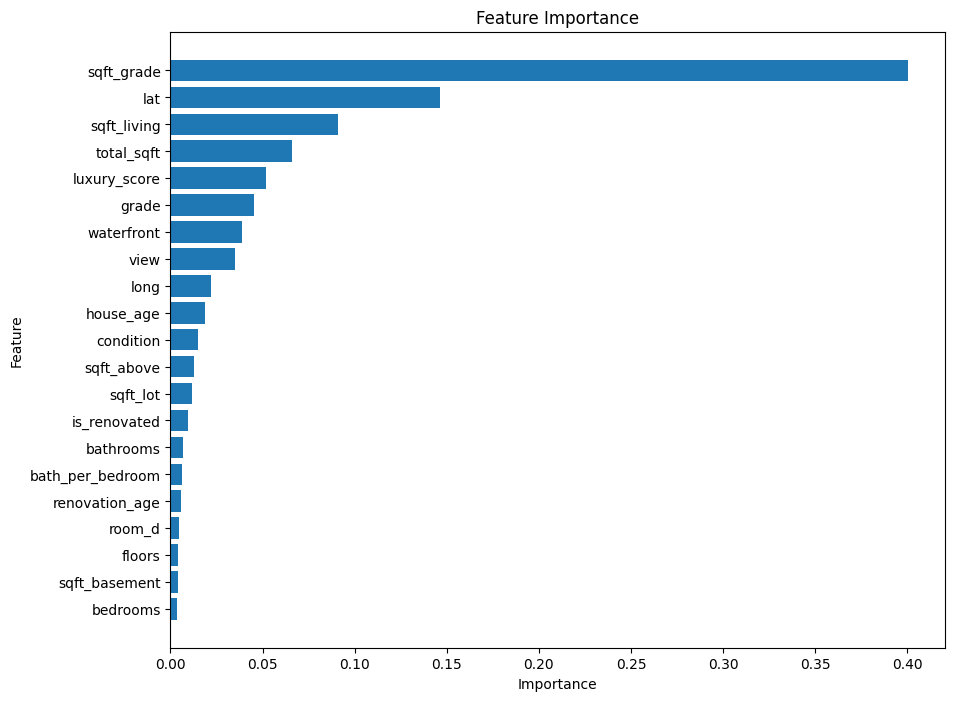

In [57]:
regressor = model.named_steps["regressor"]
feature_names = FEATURES
importances = regressor.feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
print(importance_df)
plt.figure(figsize=(10, 8))
plt.barh(importance_df["Feature"],importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.show()

In [58]:
joblib.dump(model, "model.pkl")
joblib.dump(FEATURES, "features.pkl")

['features.pkl']